# 02 — Classification: Probability of Default (PD)

**How to use this notebook:** run each cell in order (Shift+Enter). Read the text
above each code cell, then the comments inside it. This module uses a **real,
open dataset** (no synthetic data) and shows three ways to import data.

## The problem in plain words
Will a credit-card customer **default** (fail to pay) next month? The answer is
yes/no, so this is a **classification** problem — and the probability of "yes"
is the **PD** (Probability of Default), the first term in the credit-risk
formula we met in module 01:

> Expected Loss ≈ **PD × LGD × EAD**

- Module 01 modelled **LGD** (how much is lost) with *regression*.
- This module models **PD** (chance of loss) with *classification*.

## The dataset
**Default of Credit Card Clients** (Taiwan, 2005) from the UCI repository —
30,000 real customers, 23 features (credit limit, age, past repayment status,
bill and payment amounts), and a 0/1 label `default.payment.next.month`.
Available on both UCI and Kaggle.

## Step 0 — How to import data (Kaggle, UCI, or any website)

You asked how to pull data from Kaggle or the web. Here are the three common
ways, easiest first. **We use Method A below** because it needs no account or
setup — but A, B, and C all fetch the *same* dataset.

### Method A — straight from a URL with pandas (no account needed)
`pandas` can read a CSV directly from a web link. Simplest method; the one this
notebook runs.

### Method B — the Kaggle API (for datasets behind a Kaggle login)
One-time setup:
1. Make a free account at kaggle.com.
2. Go to **Account → Settings → API → Create New Token**. This downloads a file
   `kaggle.json` (your key).
3. Put it where Kaggle looks for it:
   - Mac/Linux: `~/.kaggle/kaggle.json`  then  `chmod 600 ~/.kaggle/kaggle.json`
   - Windows: `C:\Users\<you>\.kaggle\kaggle.json`
4. Install the client and download:
```bash
pip install kaggle
kaggle datasets download -d uciml/default-of-credit-card-clients-dataset --unzip
```
Then `pd.read_csv("UCI_Credit_Card.csv")`.

### Method C — kagglehub (newest, fewest steps)
```python
import kagglehub, pandas as pd, os
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
df = pd.read_csv(os.path.join(path, "UCI_Credit_Card.csv"))
```

### Bonus — the official UCI package
```python
pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
ds = fetch_ucirepo(id=350)           # 350 = this dataset
X, y = ds.data.features, ds.data.targets
```


### Setup: imports

In [1]:
import numpy as np                 # fast maths on arrays
import pandas as pd                # tables (rows/columns)
import matplotlib.pyplot as plt    # charts
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss)
from sklearn.calibration import calibration_curve

SEED = 42
print("Libraries loaded.")

Libraries loaded.


### Load the data (Method A: direct from URL, with an offline fallback)

In [2]:
DATA_URL = "https://raw.githubusercontent.com/robertofranceschi/default-credit-card-prediction/master/dataset/default%20of%20credit%20card%20clients.csv"

def load_data():
    # Try the real dataset first (needs internet). pandas reads CSV from a URL.
    try:
        df = pd.read_csv(DATA_URL)
        print("Loaded REAL UCI data from the web.")
        return df
    except Exception as e:
        # If you're offline, make a tiny stand-in so the notebook still runs.
        print("Could not download (offline?) -> using synthetic fallback.", e)
        rng = np.random.default_rng(SEED); n = 5000
        d = pd.DataFrame({
            "LIMIT_BAL": rng.lognormal(11, .5, n).round(-3),
            "AGE": rng.integers(21, 70, n),
            "PAY_0": rng.integers(-2, 4, n),
            "BILL_AMT1": rng.normal(40000, 30000, n).round(),
            "PAY_AMT1": rng.normal(5000, 4000, n).clip(0).round()})
        z = -1 + 0.9*d["PAY_0"] - 0.00002*d["PAY_AMT1"]
        d["default.payment.next.month"] = (rng.uniform(size=n) < 1/(1+np.exp(-z))).astype(int)
        return d

df = load_data()
print("shape:", df.shape)
df.head(3)

Loaded REAL UCI data from the web.
shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0


## Step 1 — Look at the data and tidy it up

The columns: `LIMIT_BAL` (credit limit), `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`,
`PAY_0..PAY_6` (recent repayment status; higher = more months late),
`BILL_AMT1..6` (past bills), `PAY_AMT1..6` (past payments), and the target
`default.payment.next.month` (1 = defaulted, 0 = paid).

In [3]:
# Rename the long target to something short, and drop ID (not predictive).
df = df.rename(columns={"default.payment.next.month": "default"})
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# The class balance is the first thing to check.
balance = df["default"].value_counts(normalize=True).round(3)
print("Class balance (0 = paid, 1 = default):", balance.to_dict())
print(f"A lazy model that always predicts 'no default' would be "
      f"{balance.get(0,0)*100:.1f}% 'accurate' -- which is why accuracy is a trap here.")

Class balance (0 = paid, 1 = default): {0: 0.779, 1: 0.221}
A lazy model that always predicts 'no default' would be 77.9% 'accurate' -- which is why accuracy is a trap here.


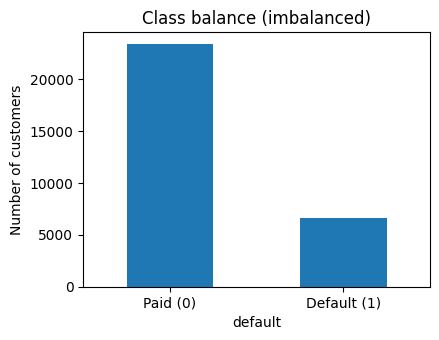

In [4]:
# Visualise the imbalance.
plt.figure(figsize=(4.5, 3.5))
df["default"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Paid (0)", "Default (1)"], rotation=0)
plt.ylabel("Number of customers"); plt.title("Class balance (imbalanced)")
plt.tight_layout(); plt.show()

## Step 2 — Logistic regression *from scratch*

For a yes/no answer we need probabilities between 0 and 1. Linear regression can
output any number, so we wrap it in the **sigmoid** function, which squashes any
value into (0, 1):
$$p = \sigma(z) = \frac{1}{1+e^{-z}}, \qquad z = w_0 + w_1x_1 + \dots$$

"Training" finds the weights that make the predicted probabilities match the
0/1 labels, measured by **log loss** (binary cross-entropy):
$$\text{loss} = -\frac{1}{m}\sum \big[y\log p + (1-y)\log(1-p)\big]$$

We minimise it with **gradient descent**. The gradient has a simple form:
`(1/m) · Xᵀ(p − y)`.

In [5]:
class LogisticRegressionScratch:
    # Our own logistic regression (binary classifier).
    def __init__(self, learning_rate=0.1, n_iterations=3000, l2=0.0):
        self.lr = learning_rate        # gradient-descent step size
        self.n_iter = n_iterations     # number of steps
        self.l2 = l2                   # optional penalty on big weights
        self.w = None; self.b = None   # weights + intercept (set during fit)
        self.loss_history = []         # log loss at each step (to plot)

    @staticmethod
    def _sigmoid(z):
        # Clip z so e^-z never overflows, then squash into (0,1).
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y, float).ravel()
        m, n = X.shape
        self.w = np.zeros(n); self.b = 0.0      # blank slate
        for _ in range(self.n_iter):
            p = self._sigmoid(X @ self.w + self.b)   # 1) predicted probabilities
            pc = np.clip(p, 1e-12, 1 - 1e-12)        # avoid log(0)
            loss = -np.mean(y*np.log(pc) + (1-y)*np.log(1-pc)) + self.l2*np.sum(self.w**2)/m
            self.loss_history.append(loss)           # 2) record the log loss
            error = p - y                            # 3) gradients from (p - y)
            dw = (X.T @ error)/m + 2*self.l2*self.w/m
            db = np.mean(error)
            self.w -= self.lr*dw                      # 4) step downhill
            self.b -= self.lr*db
        return self

    def predict_proba(self, X):
        return self._sigmoid(np.asarray(X, float) @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
print("LogisticRegressionScratch defined.")

LogisticRegressionScratch defined.


## Step 3 — Split, scale, and train

- **Stratified split**: keep the same 22% default rate in both train and test.
- **Scale**: standardise features so gradient descent converges and coefficients
  are comparable. Fit the scaler on train only (no peeking at test).

In [6]:
X = df.drop(columns=["default"]).astype(float)   # all features
y = df["default"].astype(int)                    # the 0/1 label
feature_names = X.columns.tolist()

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)   # stratify keeps ratios

scaler = StandardScaler().fit(X_tr)              # learn scaling from train only
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
print("Train:", X_tr_s.shape, " Test:", X_te_s.shape)

Train: (22500, 23)  Test: (7500, 23)


### Train our from-scratch model and watch the loss fall

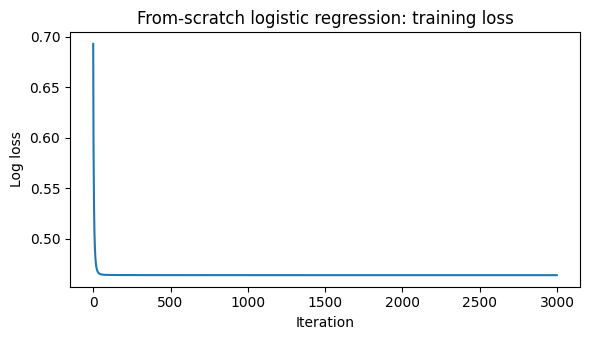

In [7]:
scratch = LogisticRegressionScratch(learning_rate=0.5, n_iterations=3000).fit(X_tr_s, y_tr)

plt.figure(figsize=(6, 3.5))
plt.plot(scratch.loss_history)
plt.xlabel("Iteration"); plt.ylabel("Log loss")
plt.title("From-scratch logistic regression: training loss")
plt.tight_layout(); plt.show()

### Train scikit-learn's version and a stronger benchmark

Two models:
- `LogisticRegression` — the interpretable PD workhorse (compare to our scratch one).
- `HistGradientBoosting` — a more powerful benchmark. In model risk you always
  ask: does the complex model beat the simple, explainable one by enough to
  justify its opacity?

`class_weight="balanced"` makes the model pay more attention to the rarer
default class.

In [8]:
logit = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr_s, y_tr)
gbm = HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED).fit(X_tr_s, y_tr)

p_scratch = scratch.predict_proba(X_te_s)
p_logit   = logit.predict_proba(X_te_s)[:, 1]
p_gbm     = gbm.predict_proba(X_te_s)[:, 1]

print(f"Test ROC-AUC | from-scratch: {roc_auc_score(y_te, p_scratch):.3f}"
      f"  sklearn logit: {roc_auc_score(y_te, p_logit):.3f}"
      f"  gboost: {roc_auc_score(y_te, p_gbm):.3f}")

Test ROC-AUC | from-scratch: 0.716  sklearn logit: 0.716  gboost: 0.778


## Step 4 — Classification metrics (the core of this module)

**Why not accuracy?** With 78% non-defaulters, always guessing "no default"
scores 78% accuracy while catching *zero* defaulters. So we use:

- **Confusion matrix** — the four outcomes: true/false × positive/negative.
- **Precision** — of those flagged as default, how many really were? (alert quality)
- **Recall (sensitivity)** — of all real defaulters, how many did we catch? (coverage)
- **F1** — the balance of precision and recall.
- **ROC-AUC** — ranking quality across thresholds (1.0 perfect, 0.5 = coin flip).
- **PR-AUC (average precision)** — like ROC but better when positives are rare.

In [9]:
pred_05 = (p_gbm >= 0.5).astype(int)    # threshold at the usual 0.5 for now

cm = confusion_matrix(y_te, pred_05)
print("Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(cm, index=["actual paid","actual default"],
                   columns=["pred paid","pred default"]))
print(f"\nAccuracy : {accuracy_score(y_te, pred_05):.3f}")
print(f"Precision: {precision_score(y_te, pred_05):.3f}  (of flagged, how many defaulted)")
print(f"Recall   : {recall_score(y_te, pred_05):.3f}  (of defaulters, how many caught)")
print(f"F1       : {f1_score(y_te, pred_05):.3f}")

Confusion matrix (rows = actual, cols = predicted):
                pred paid  pred default
actual paid          4611          1230
actual default        621          1038

Accuracy : 0.753
Precision: 0.458  (of flagged, how many defaulted)
Recall   : 0.626  (of defaulters, how many caught)
F1       : 0.529


### ROC and Precision-Recall curves

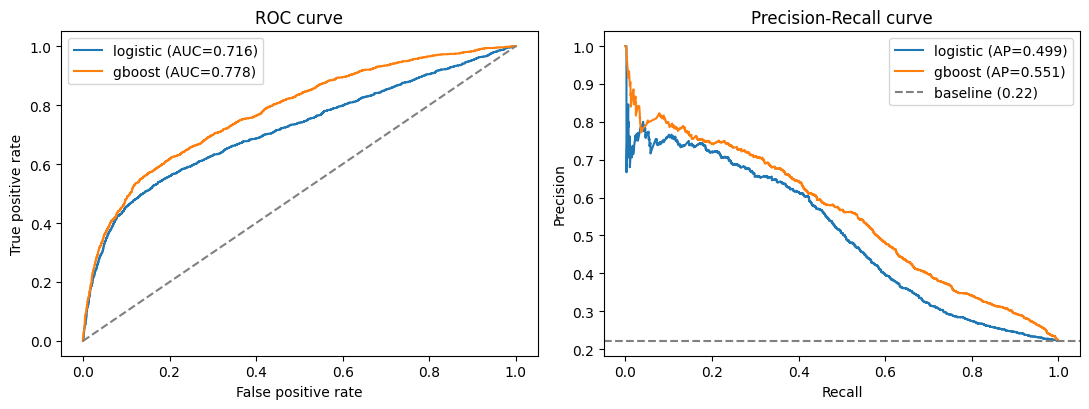

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# ROC: true-positive rate vs false-positive rate at every threshold.
for name, p in [("logistic", p_logit), ("gboost", p_gbm)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, p):.3f})")
ax[0].plot([0,1],[0,1],"--",color="gray")        # the coin-flip diagonal
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend()

# PR: precision vs recall. Better than ROC when positives are rare.
for name, p in [("logistic", p_logit), ("gboost", p_gbm)]:
    prec, rec, _ = precision_recall_curve(y_te, p)
    ax[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_te, p):.3f})")
ax[1].axhline(y_te.mean(), ls="--", color="gray", label=f"baseline ({y_te.mean():.2f})")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall curve"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 5 — Choosing the decision threshold (a business choice)

The model outputs a *probability*; 0.5 is just a default cut-off, not a law.
In banking, **missing a defaulter (false negative) costs far more** than a false
alarm. So we pick the threshold that minimises expected cost. Here a missed
default costs ~5× a false alarm.

Cost-minimising threshold: 0.39 (vs the default 0.50)


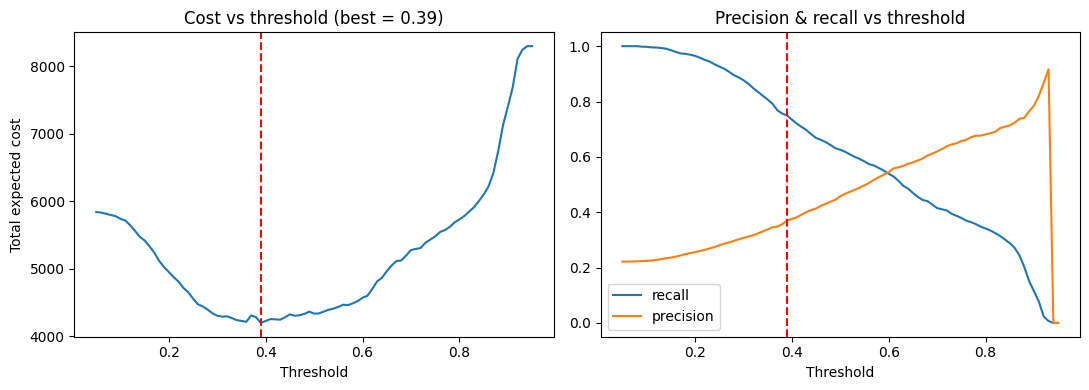

In [11]:
COST_FN = 5.0   # cost of missing a real defaulter
COST_FP = 1.0   # cost of a false alarm (lost business / friction)

thresholds = np.linspace(0.05, 0.95, 91)
costs, recalls, precisions = [], [], []
for t in thresholds:
    pred = (p_gbm >= t).astype(int)
    fn = int(((y_te == 1) & (pred == 0)).sum())   # missed defaulters
    fp = int(((y_te == 0) & (pred == 1)).sum())   # false alarms
    costs.append(fn*COST_FN + fp*COST_FP)
    recalls.append(recall_score(y_te, pred))
    precisions.append(precision_score(y_te, pred, zero_division=0))

best_t = thresholds[int(np.argmin(costs))]
print(f"Cost-minimising threshold: {best_t:.2f} (vs the default 0.50)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(thresholds, costs); ax[0].axvline(best_t, color="red", ls="--")
ax[0].set_xlabel("Threshold"); ax[0].set_ylabel("Total expected cost")
ax[0].set_title(f"Cost vs threshold (best = {best_t:.2f})")
ax[1].plot(thresholds, recalls, label="recall")
ax[1].plot(thresholds, precisions, label="precision")
ax[1].axvline(best_t, color="red", ls="--")
ax[1].set_xlabel("Threshold"); ax[1].set_title("Precision & recall vs threshold"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 6 — Calibration (critical for a PD model)

A PD model's probabilities feed capital and provisioning calculations, so they
must be **calibrated**: among customers given a "20% PD", about 20% should
actually default. We check with a reliability diagram and the **Brier score**
(lower = better).

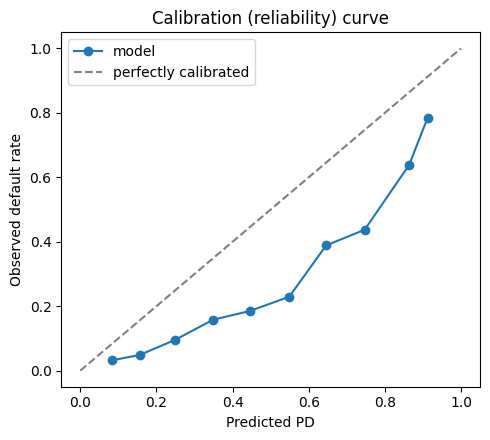

Brier score (lower is better): 0.1793


In [12]:
frac_pos, mean_pred = calibration_curve(y_te, p_gbm, n_bins=10)
plt.figure(figsize=(5, 4.5))
plt.plot(mean_pred, frac_pos, "o-", label="model")
plt.plot([0,1],[0,1],"--",color="gray", label="perfectly calibrated")
plt.xlabel("Predicted PD"); plt.ylabel("Observed default rate")
plt.title("Calibration (reliability) curve"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Brier score (lower is better): {brier_score_loss(y_te, p_gbm):.4f}")

## Step 7 — What drives default? (coefficients as odds ratios)

For logistic regression, exponentiating a coefficient gives an **odds ratio**:
how the odds of default multiply per 1-standard-deviation increase in that
feature. `PAY_0` (the most recent repayment status) usually dominates — being
late last month is the strongest signal of defaulting next month.

In [13]:
odds = pd.DataFrame({
    "feature": feature_names,
    "coef": logit.coef_[0],
    "odds_ratio": np.exp(logit.coef_[0]).round(3)})
odds = odds.reindex(odds.coef.abs().sort_values(ascending=False).index).reset_index(drop=True)
odds.head(10)

,feature,coef,odds_ratio
0,PAY_0,0.579874,1.786
1,BILL_AMT1,-0.281121,0.755
2,PAY_AMT2,-0.198271,0.820
3,PAY_AMT1,-0.166476,0.847
4,LIMIT_BAL,-0.126644,0.881
5,PAY_2,0.109273,1.115
6,EDUCATION,-0.094797,0.910
7,BILL_AMT3,0.092278,1.097
8,PAY_3,0.089776,1.094
9,AGE,0.077706,1.081


## Interview prep — answer these out loud

**Conceptual**
1. *Why is accuracy misleading here?* With 78% one class, predicting the majority
   scores 78% yet catches no defaulters. Use precision/recall/AUC instead.
2. *Precision vs recall?* Precision = of those flagged, how many were right;
   recall = of all real positives, how many we caught. Usually a trade-off.
3. *ROC-AUC vs PR-AUC?* ROC can look optimistic when positives are rare; PR-AUC
   focuses on the positive (default) class, so it's often more honest for imbalance.
4. *Sigmoid / log loss?* Sigmoid maps any number to a (0,1) probability; log loss
   penalises confident wrong predictions heavily.
5. *Why move the threshold off 0.5?* It's arbitrary; choose it by business cost or
   a target recall. Missing a defaulter usually costs more than a false alarm.
6. *Handling class imbalance?* class_weight, resampling (SMOTE), threshold tuning,
   and the right metrics. We used class_weight + threshold tuning.

**Model Risk flavoured**
7. *Why does calibration matter for PD?* PDs feed capital/provisioning; a "10% PD"
   must mean ~10% real default rate. Check with a reliability curve and Brier score.
8. *Logistic vs gradient boosting for PD?* Logistic is transparent and easy to
   defend to a regulator; boosting may rank better but is opaque. Justify the
   complex model only if its uplift is real and explainable (e.g. SHAP).
9. *How would you validate this model?* Out-of-time testing, score-distribution
   stability (PSI), discrimination (AUC) and calibration over time, fairness across
   protected groups, and clear documentation.

## Limitations (say these unprompted)
- `EDUCATION` and `MARRIAGE` contain undocumented categories (0, 5, 6); a real
  build would clean or group these.
- `PAY_0..PAY_6` are point-in-time; real PD models use longer behavioural windows
  and out-of-*time* validation, not just a random split.
- Probabilities should be monitored for drift after deployment.

---
**Next module:** `03_anomaly_detection` — finding unusual transactions/accounts
*without* labels (Isolation Forest, and the idea of learning "normal").